In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [4]:
file_path="../data/raw/online_retail_II.xlsx" 
excel_data=pd.read_excel(
    file_path,
    sheet_name=None
)

excel_data.keys()

dict_keys(['Year 2009-2010', 'Year 2010-2011'])

In [5]:
df=pd.concat(
    excel_data.values(),
    ignore_index=True
)

In [6]:
df.head()
df.tail()
df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
982729,575739,21868,POTTING SHED TEA MUG,1,2011-11-11 09:05:00,3.29,NaN,United Kingdom
155970,C504174,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-1,2010-04-12 08:09:00,2.95,15079.0,United Kingdom
192215,507640,22624,IVORY KITCHEN SCALES,3,2010-05-10 14:58:00,8.50,13319.0,United Kingdom
670030,548749,37447,CERAMIC CAKE DESIGN SPOTTED PLATE,12,2011-04-04 12:29:00,1.49,13004.0,United Kingdom
15861,490711,85171,S/2 HYACINTH BULB CANDLES,1,2009-12-07 15:26:00,2.55,17841.0,United Kingdom


In [7]:
df.describe()
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


In [8]:
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [9]:
missing=df.isnull().sum()
missing

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [10]:
missing_percentage=(
    df.isnull().mean()*100
).sort_values(ascending=False)
missing_percentage

Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

In [11]:
missing_report=pd.DataFrame({
    "missing_count":df.isnull().sum(),
    "missing_percentage":df.isnull().mean()*100
})
missing_report=missing_report.sort_values(
    "missing_percentage",
    ascending=False
)
missing_report

,missing_count,missing_percentage
Customer ID,243007,22.766873
Description,4382,0.410541
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


In [12]:
duplicate_count=df.duplicated().sum()
duplicate_count

np.int64(34335)

In [13]:
duplicate_percentage=(
    df.duplicated().mean()*100
)
duplicate_percentage

np.float64(3.2167821685243467)

In [14]:
df.nunique().sort_values()

Country           43
Quantity        1057
Price           2807
StockCode       5305
Description     5698
Customer ID     5942
InvoiceDate    47635
Invoice        53628
dtype: int64

In [15]:
df["Country"].nunique()
df["Country"].value_counts().head(20)

Country
United Kingdom     981330
EIRE                17866
Germany             17624
France              14330
Netherlands          5140
Spain                3811
Switzerland          3189
Belgium              3123
Portugal             2620
Australia            1913
Channel Islands      1664
Italy                1534
Norway               1455
Sweden               1364
Cyprus               1176
Finland              1049
Austria               938
Denmark               817
Unspecified           756
Greece                663
Name: count, dtype: int64

In [16]:
df["StockCode"].nunique()
df["Customer ID"].nunique()
df["Invoice"].nunique()

53628

In [17]:
df["Invoice"].astype(str).str.startswith("C").value_counts()
cancelled=df[
    df["Invoice"].astype(str).str.startswith("C")
]
cancelled.shape
cancelled.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [18]:
(df["Quantity"]<0).sum()
df[df["Quantity"]<0].head()
(df["Price"]<0).sum()

np.int64(5)

In [19]:
df["InvoiceDate"].min()
df["InvoiceDate"].max()
df["InvoiceDate"].isna().sum()


np.int64(0)

In [20]:
df["Revenue"]=df["Quantity"]*df["Price"]
df[["Quantity","Price","Revenue"]].head()
df["Revenue"].describe()
df["Revenue"].sum()

np.float64(19287250.568)

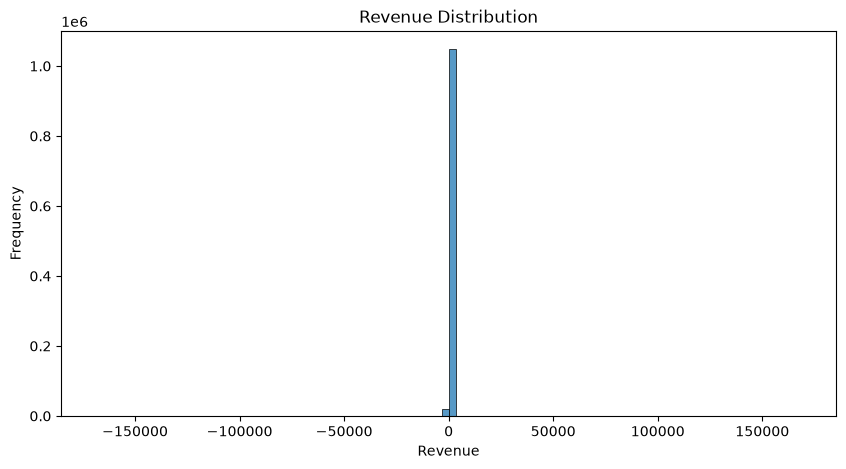

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Revenue"],
    bins=100
)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [22]:
profiling_report = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "duplicate_rows": int(df.duplicated().sum()),
    "total_missing_values": int(df.isnull().sum().sum()),
    "unique_customers": int(df["Customer ID"].nunique()),
    "unique_products": int(df["StockCode"].nunique()),
    "unique_invoices": int(df["Invoice"].nunique()),
    "unique_countries": int(df["Country"].nunique()),
    "total_revenue": float(df["Revenue"].sum())
}

profiling_report

{'rows': 1067371,
 'columns': 9,
 'duplicate_rows': 34335,
 'total_missing_values': 247389,
 'unique_customers': 5942,
 'unique_products': 5305,
 'unique_invoices': 53628,
 'unique_countries': 43,
 'total_revenue': 19287250.568}

In [23]:
import sys
sys.path.append("../")

In [24]:
from src.analysis.eda import calculate_sales_metrics,monthly_sales

In [25]:
from src.utils.cleaner import clean_data

In [26]:
cleaned_df=clean_data(df)

In [27]:
cleaned_df.shape

(1033036, 11)

In [28]:
sales_metrics = calculate_sales_metrics(cleaned_df)

sales_metrics

{'total_revenue': 18855533.698,
 'total_transactions': 53628,
 'total_products': 5305,
 'total_customers': 5942,
 'total_countries': 43,
 'average_order_value': 351.5986741627508}

In [29]:
cleaned_df.columns.tolist()

['invoice',
 'stock_code',
 'description',
 'quantity',
 'invoice_date',
 'price',
 'customer_id',
 'country',
 'Revenue',
 'is_cancelled',
 'revenue']

In [30]:
monthly=monthly_sales(cleaned_df)
monthly.head()

,year_month,revenue
0,2009-12-01,796648.500
1,2010-01-01,622479.502
2,2010-02-01,531265.366
3,2010-03-01,763247.241
4,2010-04-01,587926.692


In [31]:
monthly.shape

(25, 2)

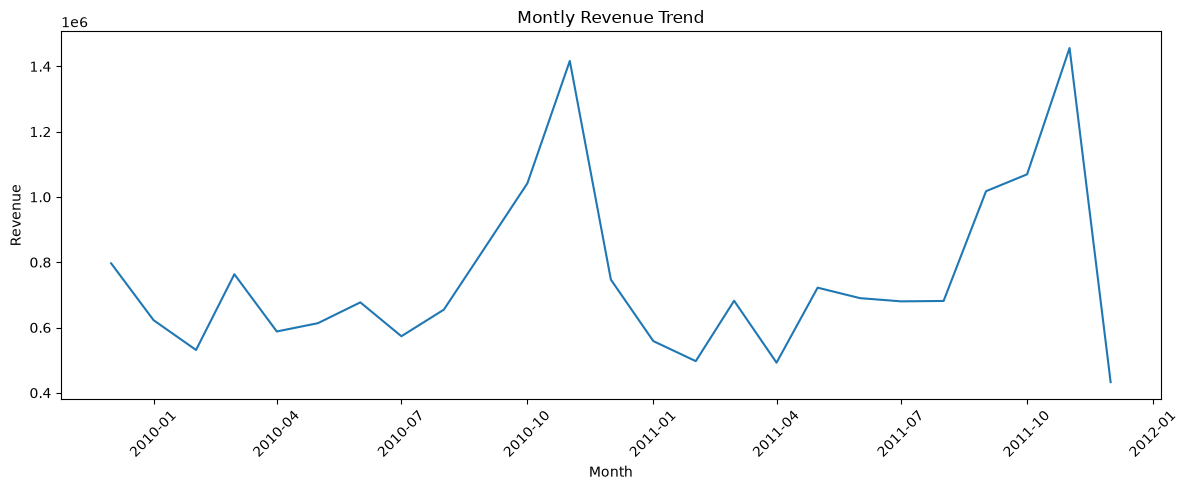

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly["year_month"],
    monthly["revenue"]
)

plt.title("Montly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
top_products=(
    cleaned_df
    .groupby("stock_code")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

stock_code
22423     314045.02
DOT       309844.10
85123A    248337.61
85099B    178400.52
47566     147079.73
84879     128550.42
22086     116298.59
POST      110430.41
79321      79905.13
22197      78903.62
Name: revenue, dtype: float64

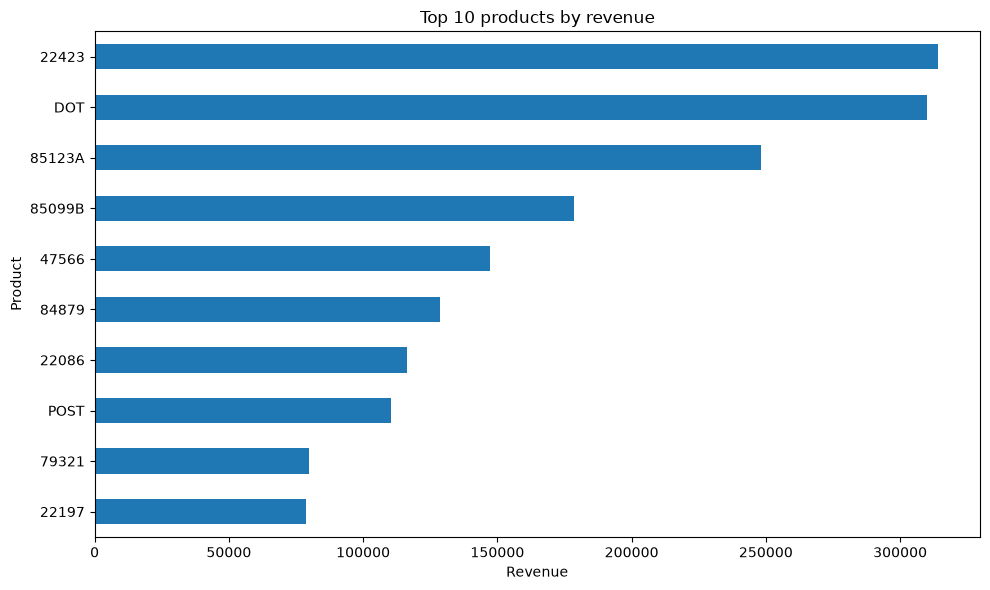

In [34]:
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 products by revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [35]:
top_countries=(
    cleaned_df
    .groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_countries

country
United Kingdom    1.598606e+07
EIRE              6.099538e+05
Netherlands       5.483307e+05
Germany           4.119592e+05
France            3.217334e+05
Australia         1.664444e+05
Switzerland       9.940306e+04
Spain             9.101344e+04
Sweden            8.777552e+04
Denmark           6.445959e+04
Name: revenue, dtype: float64

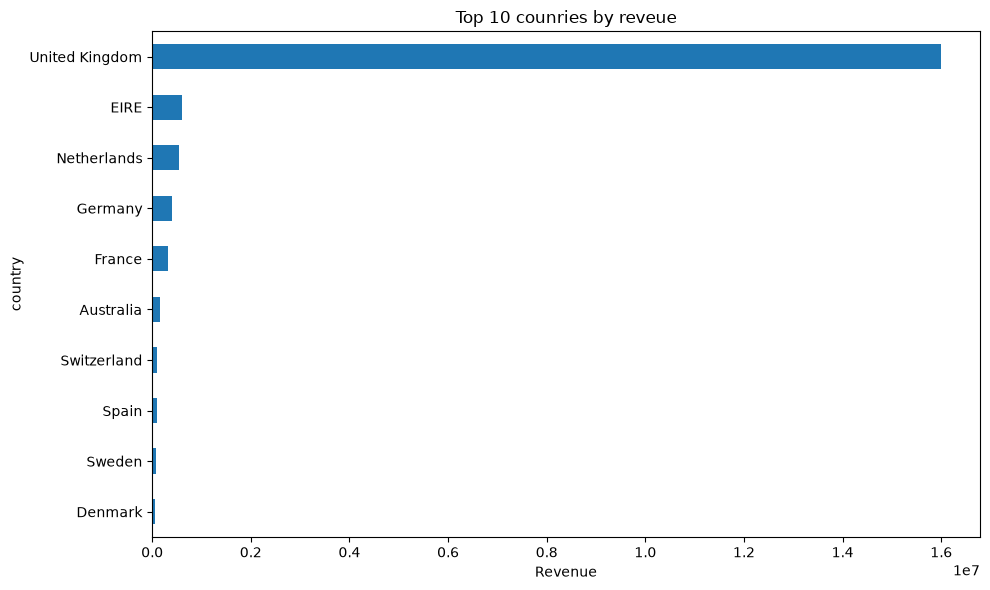

In [36]:
plt.figure(figsize=(10,6))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 10 counries by reveue")
plt.xlabel("Revenue")
plt.ylabel("country")
plt.tight_layout()
plt.show()

In [37]:
customer_revenue=(
    cleaned_df
    .groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
)
customer_revenue.head(20)

customer_id
18102.0    570380.61
14646.0    523342.07
14156.0    296063.44
14911.0    265757.91
17450.0    231390.55
13694.0    190020.84
17511.0    168491.62
12415.0    143269.29
16684.0    141502.25
15061.0    124961.98
15311.0    111739.36
13089.0    109893.24
17949.0     97581.59
14298.0     90489.31
16029.0     89705.47
15769.0     84177.58
13798.0     73166.92
15838.0     72727.41
12931.0     71299.67
17841.0     67186.87
Name: revenue, dtype: float64

In [8]:
from src.analysis.eda import(
    calculate_sales_metrics,
    monthly_sales,
    top_products,
    top_countries,
    customer_revenue
)

In [3]:
import sys

print(sys.executable)

c:\Project\Data Science\Autonomous Data Analyst\.venv\Scripts\python.exe


In [7]:
import importlib
import src.analysis.eda as eda

importlib.reload(eda)

print(eda.__file__)
print([x for x in dir(eda) if not x.startswith("_")])

c:\Project\Data Science\Autonomous Data Analyst\src\analysis\eda.py
['calculate_sales_metrics', 'customer_revenue', 'monthly_sales', 'pd', 'top_countries', 'top_products']


In [5]:
import sys 
import os 
sys.path.insert(0,os.path.abspath(".."))
print(os.getcwd())
print(sys.path[0])

c:\Project\Data Science\Autonomous Data Analyst\notebooks
c:\Project\Data Science\Autonomous Data Analyst


In [6]:
import src.analysis.eda as eda
print(eda.__file__)
print([x for x in dir(eda) if not x.startswith("_")])

c:\Project\Data Science\Autonomous Data Analyst\src\analysis\eda.py
['calculate_sales_metrics', 'customer_revenue', 'monthly_sales', 'pd', 'top_countries', 'top_products']


In [9]:
products=top_products(cleaned_df)
products.head(10)

NameError: name 'cleaned_df' is not defined

In [ ]:
countries=top_countries(cleaned_df)
countries.head(10)

In [ ]:
customers=customer_revenue(cleaned_df)
customers.head(10)

In [ ]:
def generate_eda_summary(df:pd.DataFrame)->dict:
    """Generate a complete high-level EDA summary."""

    return {
        "sales_metrics":calculate_sales_metrics(df),
        "monthly_sales":monthly_sales(df),
        "top_prodcuts": top_products(df),
        "top_countries":top_countries(df),
        "customer_revenue":customer_revenue(df)
    }

In [ ]:
from src.analysis.eda import generate_eda_summary

In [ ]:
eda_summary=generate_eda_summary(cleaned_df)

In [ ]:
eda_summary.keys()